# Importando o Pandas e resgatando as colunas disponíveis no Dataset da empresa


In [2]:
from pathlib import Path
import pandas as pd

# O notebook vive em backend/notebooks/, o dataset em backend/data/.
# .parent sobe um nivel (de notebooks/ para backend/) e de la acessa data/.
BASE_DIR = Path.cwd().parent
DATA_PATH = BASE_DIR / "data" / "LW-DATASET.xlsx"

# Se o cwd nao for a pasta do notebook (acontece em algumas configs do VS Code),
# descomente a linha abaixo e ajuste manualmente:
# DATA_PATH = Path("../data/LW-DATASET.xlsx")

print("Lendo:", DATA_PATH.resolve())

df = pd.read_excel(DATA_PATH)

print('Linhas e colunas:', df.shape)
print()
print('Colunas disponiveis:')
for col in df.columns:
    print(' -', col)

Linhas e colunas: (122543, 19)

Colunas disponíveis:
 - Número
 - Prioridade
 - Produto
 - Categoria
 - Subcategoria
 - Grupo designado
 - Item de configuração
 - Aberto
 - Resolvido
 - Encerrado
 - Duração
 - Código de fechamento
 - Descrição resumida
 - Solução
 - Aberto por
 - Incidente Pai
 - Status
 - Entrou para KPI?
 - KPI Violado?


# Trazendo 3 primeiras linhas de cada coluna e entendendo formato de cada uma das colunas

In [3]:
print('Primeiras 3 linhas:')
print(df.head(3))
print()
print('Tipos de cada coluna:')
print(df.dtypes)

Primeiras 3 linhas:
       Número Prioridade Produto Categoria Subcategoria Grupo designado  \
0  INC8654273  3 - Média     NaN       NaN          NaN          Team14   
1  INC8654270  4 - Baixa     NaN       NaN          NaN          Team14   
2  INC8654264  4 - Baixa     NaN       NaN          NaN          Team14   

  Item de configuração              Aberto Resolvido           Encerrado  \
0              IC00001 2025-12-31 23:45:18       NaT 2025-12-31 23:45:32   
1              IC00002 2025-12-31 23:39:36       NaT 2025-12-31 23:43:05   
2                  NaN 2025-12-31 23:23:10       NaT 2025-12-31 23:25:00   

   Duração Código de fechamento  \
0       14                  NaN   
1      209                  NaN   
2      110                  NaN   

                                  Descrição resumida Solução     Aberto por  \
0                       Problem: Apache Busy Workers     NaN  Monitoramento   
1              Problem: Check Application Monitoring     NaN  Monitoramento

# Explorando os dados por prioridade, status, forma de abertura e período

In [4]:
print('=== DISTRIBUIÇÃO POR PRIORIDADE ===')
print(df['Prioridade'].value_counts())
print()
print('=== STATUS DOS INCIDENTES ===')
print(df['Status'].value_counts())
print()
print('=== ABERTO POR ===')
print(df['Aberto por'].value_counts())
print()
print('=== PERÍODO DOS DADOS ===')
print('Mais antigo:', df['Aberto'].min())
print('Mais recente:', df['Aberto'].max())

=== DISTRIBUIÇÃO POR PRIORIDADE ===
Prioridade
4 - Baixa          64828
3 - Média          41732
2 - Alta           15649
5 - Muito Baixa      333
1 - Crítica            1
Name: count, dtype: int64

=== STATUS DOS INCIDENTES ===
Status
Sem Intervenção              80373
Encerrado Automaticamente    26830
Encerrado                    15339
Aguardando Problema              1
Name: count, dtype: int64

=== ABERTO POR ===
Aberto por
Monitoramento    104299
Manual            18244
Name: count, dtype: int64

=== PERÍODO DOS DADOS ===
Mais antigo: 2023-01-02 20:19:58
Mais recente: 2025-12-31 23:45:18


# Explorando quantos chamados entraram para KPI, se o mesmo foi violado e quais categorias são responsáveis pelas violações

In [5]:
print('=== ENTROU PARA KPI ===')
print(df['Entrou para KPI?'].value_counts())
print()

kpi_df = df[df['Entrou para KPI?'] == 'SIM']
print('Total de incidentes no KPI:', len(kpi_df))
print()

print('=== KPI VIOLADO ===')
print(kpi_df['KPI Violado?'].value_counts())
print()

violados = kpi_df[kpi_df['KPI Violado?'] == 'SIM']
print('Total de violações:', len(violados))
print()

print('=== VIOLAÇÕES POR PRIORIDADE ===')
print(violados['Prioridade'].value_counts())

=== ENTROU PARA KPI ===
Entrou para KPI?
NAO    96943
SIM    25600
Name: count, dtype: int64

Total de incidentes no KPI: 25600

=== KPI VIOLADO ===
KPI Violado?
NAO    25352
SIM      248
Name: count, dtype: int64

Total de violações: 248

=== VIOLAÇÕES POR PRIORIDADE ===
Prioridade
3 - Média    206
2 - Alta      42
Name: count, dtype: int64


# Filtra apenas os incidentes que entram para o KPI

In [6]:
kpi_df = df[df['Entrou para KPI?'] == 'SIM']

# Engenharia de features temporais
# Extrai informações úteis da data de abertura do incidente

In [7]:
df['Aberto'] = pd.to_datetime(df['Aberto'])

df['ano'] = df['Aberto'].dt.year
df['mes'] = df['Aberto'].dt.month
df['dia_semana'] = df['Aberto'].dt.dayofweek  # 0 = segunda, 6 = domingo
df['hora'] = df['Aberto'].dt.hour

print('Novas colunas criadas com sucesso.')
print()
print(df[['Aberto', 'ano', 'mes', 'dia_semana', 'hora']].head(5))

Novas colunas criadas com sucesso.

               Aberto   ano  mes  dia_semana  hora
0 2025-12-31 23:45:18  2025   12           2    23
1 2025-12-31 23:39:36  2025   12           2    23
2 2025-12-31 23:23:10  2025   12           2    23
3 2025-12-31 23:23:07  2025   12           2    23
4 2025-12-31 23:23:05  2025   12           2    23


# Converte duração de segundos para horas
# Facilita a leitura e a comparação com os limites de OLA

In [8]:
df['duracao_horas'] = df['Duração'] / 3600

# Cria uma coluna com o limite de OLA em segundos por prioridade
limites_ola = {
    '1 - Crítica': 14400,
    '2 - Alta':    14400,
    '3 - Média':   43200,
    '4 - Baixa':   86400,
    '5 - Muito Baixa': 345600
}

df['limite_ola'] = df['Prioridade'].map(limites_ola)

print('Colunas de duração e limite OLA criadas.')
print()
print(df[['Prioridade', 'Duração', 'duracao_horas', 'limite_ola']].head(8))

Colunas de duração e limite OLA criadas.

  Prioridade  Duração  duracao_horas  limite_ola
0  3 - Média       14       0.003889       43200
1  4 - Baixa      209       0.058056       86400
2  4 - Baixa      110       0.030556       86400
3  4 - Baixa      110       0.030556       86400
4  4 - Baixa       42       0.011667       86400
5  4 - Baixa      187       0.051944       86400
6  4 - Baixa        2       0.000556       86400
7  3 - Média     1258       0.349444       43200


# Importando Matplotlib e contando incidentes por dia da semana

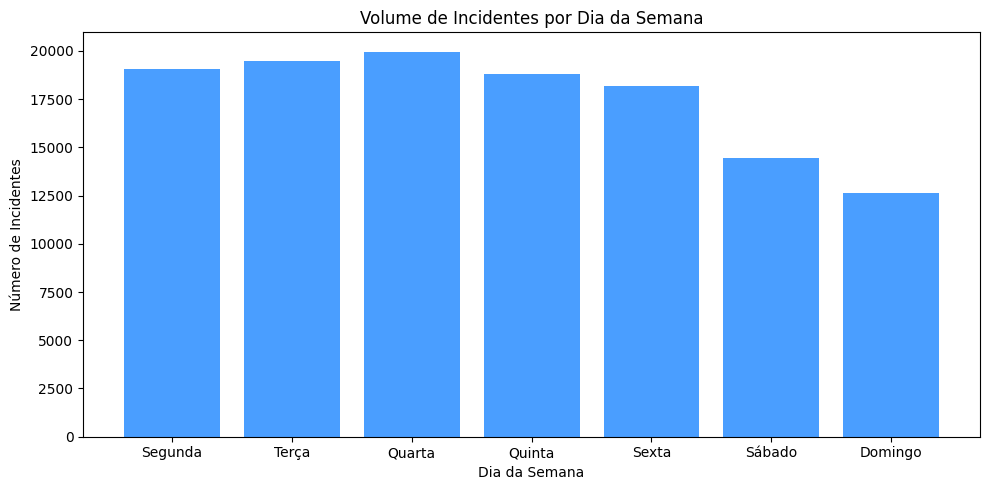

In [9]:
import matplotlib.pyplot as plt

por_dia = df.groupby('dia_semana').size()

dias = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']

plt.figure(figsize=(10, 5))
plt.bar(dias, por_dia.values, color='#4a9eff')
plt.title('Volume de Incidentes por Dia da Semana')
plt.xlabel('Dia da Semana')
plt.ylabel('Número de Incidentes')
plt.tight_layout()
plt.show()

# Volume de incidentes por hora do dia

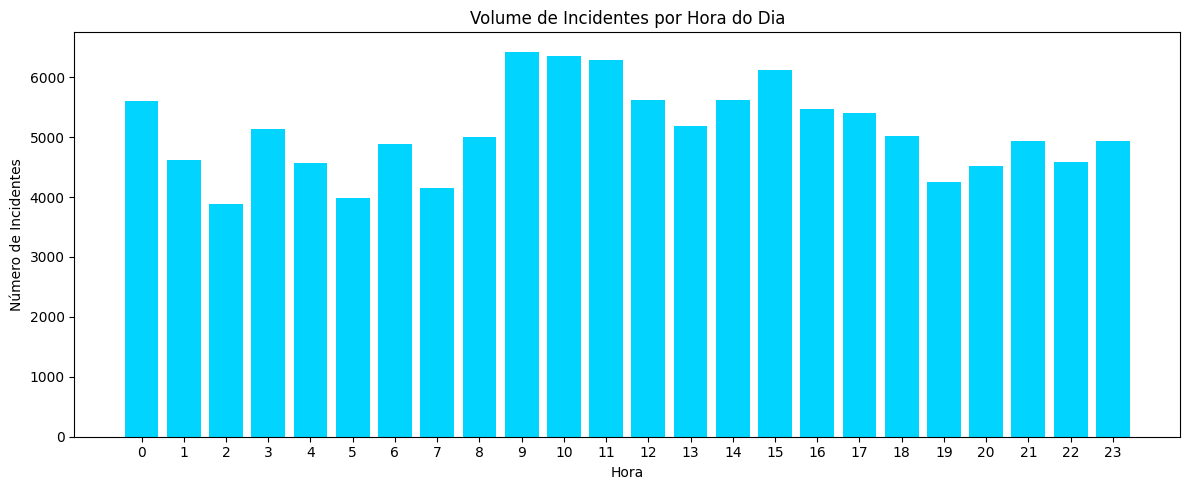

In [10]:
por_hora = df.groupby('hora').size()

plt.figure(figsize=(12, 5))
plt.bar(por_hora.index, por_hora.values, color='#00d4ff')
plt.title('Volume de Incidentes por Hora do Dia')
plt.xlabel('Hora')
plt.ylabel('Número de Incidentes')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()